<a href="https://colab.research.google.com/github/solokind/AI-Based-Smart-Patient-Monitoring-and-Risk-Prediction-System/blob/main/AI_Patient_Monitoring_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy matplotlib scikit-learn reportlab


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 22.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

np.random.seed(42)

rows = 200

data = {
    "timestamp": [datetime.now() + timedelta(minutes=i) for i in range(rows)],
    "heart_rate": np.random.normal(80, 10, rows),
    "temperature": np.random.normal(37, 0.5, rows),
    "spo2": np.random.normal(97, 2, rows),
    "systolic_bp": np.random.normal(120, 10, rows)
}

df = pd.DataFrame(data)
df.head()


,timestamp,heart_rate,temperature,spo2,systolic_bp
0,2026-02-17 05:55:34.333985,84.967142,37.178894,93.811145,127.569886
1,2026-02-17 05:56:34.333996,78.617357,37.280392,95.801250,110.778347
2,2026-02-17 05:57:34.333999,86.476885,37.541526,97.010487,128.696059
3,2026-02-17 05:58:34.334001,95.230299,37.526901,97.093961,133.556379
4,2026-02-17 05:59:34.334002,77.658466,36.311165,96.099869,124.134349


In [3]:
df = df.round(2)
df.describe()


,timestamp,heart_rate,temperature,spo2,systolic_bp
count,200,200.000000,200.000000,200.000000,200.000000
mean,2026-02-17 07:35:04.334152192,79.592400,37.043150,96.828550,120.089450
min,2026-02-17 05:55:34.333985,53.800000,35.380000,92.060000,93.030000
25%,2026-02-17 06:45:19.334074624,72.950000,36.697500,95.410000,112.937500
50%,2026-02-17 07:35:04.334151424,79.960000,37.040000,96.845000,120.220000
75%,2026-02-17 08:24:49.334226432,85.010000,37.342500,98.142500,126.855000
max,2026-02-17 09:14:34.334323,107.200000,38.930000,103.160000,146.320000
std,NaN,9.310268,0.493869,1.988158,10.195736


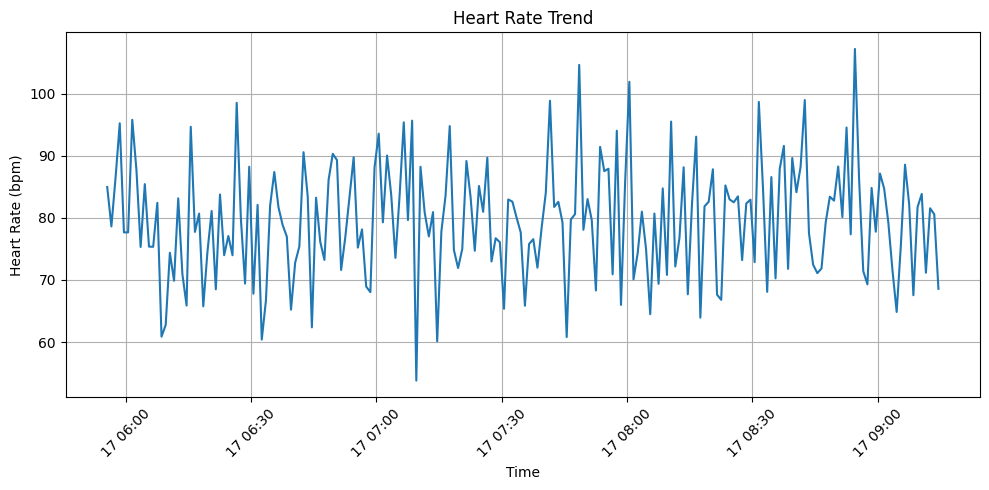

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))  # better size for readability

plt.plot(df['timestamp'], df['heart_rate'])

plt.xticks(rotation=45)
plt.title("Heart Rate Trend")
plt.xlabel("Time")
plt.ylabel("Heart Rate (bpm)")

plt.grid(True)          # adds grid lines
plt.tight_layout()      # prevents label overlapping

plt.show()



In [6]:
def check_condition(row):
    if row['heart_rate'] > 100 or row['spo2'] < 94:
        return "Critical"
    elif row['heart_rate'] > 90:
        return "Warning"
    else:
        return "Normal"

df['status'] = df.apply(check_condition, axis=1)
df.tail()


,timestamp,heart_rate,temperature,spo2,systolic_bp,status
195,2026-02-17 09:10:34.334317,83.85,36.77,95.98,130.53,Normal
196,2026-02-17 09:11:34.334318,71.16,36.14,96.46,119.60,Normal
197,2026-02-17 09:12:34.334320,81.54,37.68,95.04,126.82,Normal
198,2026-02-17 09:13:34.334321,80.58,36.94,96.11,120.28,Normal
199,2026-02-17 09:14:34.334323,68.57,37.62,97.75,120.30,Normal


In [7]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.05)

features = df[['heart_rate','temperature','spo2','systolic_bp']]
df['anomaly'] = model.fit_predict(features)

df['anomaly'] = df['anomaly'].map({1:"Normal",-1:"Anomaly"})
df.head()


,timestamp,heart_rate,temperature,spo2,systolic_bp,status,anomaly
0,2026-02-17 05:55:34.333985,84.97,37.18,93.81,127.57,Critical,Normal
1,2026-02-17 05:56:34.333996,78.62,37.28,95.80,110.78,Normal,Normal
2,2026-02-17 05:57:34.333999,86.48,37.54,97.01,128.70,Normal,Normal
3,2026-02-17 05:58:34.334001,95.23,37.53,97.09,133.56,Warning,Normal
4,2026-02-17 05:59:34.334002,77.66,36.31,96.10,124.13,Normal,Normal


In [8]:
def risk_score(row):
    score = 0

    if row['heart_rate'] > 100:
        score += 30
    if row['spo2'] < 94:
        score += 40
    if row['temperature'] > 38:
        score += 20

    return min(score,100)

df['risk_score'] = df.apply(risk_score, axis=1)


In [9]:
from sklearn.linear_model import LinearRegression

df['time_index'] = range(len(df))

X = df[['time_index']]
y = df['heart_rate']

model = LinearRegression()
model.fit(X, y)

future_index = [[len(df)+10]]
prediction = model.predict(future_index)

print("Predicted Heart Rate:", prediction[0])


Predicted Heart Rate: 80.85801576539413


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [11]:
from reportlab.platypus import SimpleDocTemplate, Paragraph
from reportlab.lib.styles import getSampleStyleSheet

doc = SimpleDocTemplate("Patient_Report.pdf")
styles = getSampleStyleSheet()
elements = []

elements.append(Paragraph("Patient Health Report", styles["Title"]))
elements.append(Paragraph(f"Average Heart Rate: {df['heart_rate'].mean():.2f}", styles["Normal"]))
elements.append(Paragraph(f"Average SpO2: {df['spo2'].mean():.2f}", styles["Normal"]))

doc.build(elements)


In [13]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib import colors
from reportlab.platypus import Table, TableStyle

doc = SimpleDocTemplate("Patient_Report.pdf")
styles = getSampleStyleSheet()
elements = []

# Title
elements.append(Paragraph("AI-Driven Patient Health Monitoring Report", styles["Title"]))
elements.append(Spacer(1, 20))

# Summary Data
avg_hr = df['heart_rate'].mean()
avg_spo2 = df['spo2'].mean()
avg_temp = df['temperature'].mean()

data = [
    ["Parameter", "Average Value"],
    ["Heart Rate (bpm)", f"{avg_hr:.2f}"],
    ["SpO2 (%)", f"{avg_spo2:.2f}"],
    ["Temperature (°C)", f"{avg_temp:.2f}"],
]

table = Table(data)
table.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.grey),
    ('GRID', (0,0), (-1,-1), 1, colors.black),
]))

elements.append(table)

doc.build(elements)


In [14]:
def generate_alert(row):
    if row['risk_score'] > 70:
        return "🚨 CRITICAL ALERT"
    elif row['risk_score'] > 40:
        return "⚠ WARNING"
    else:
        return "Normal"

df['alert_level'] = df.apply(generate_alert, axis=1)

df[['heart_rate','spo2','temperature','risk_score','alert_level']].tail()


,heart_rate,spo2,temperature,risk_score,alert_level
195,83.85,95.98,36.77,0,Normal
196,71.16,96.46,36.14,0,Normal
197,81.54,95.04,37.68,0,Normal
198,80.58,96.11,36.94,0,Normal
199,68.57,97.75,37.62,0,Normal


In [15]:
latest = df.iloc[-1]

print("Latest Patient Status")
print("-----------------------")
print("Heart Rate:", latest['heart_rate'])
print("SpO2:", latest['spo2'])
print("Temperature:", latest['temperature'])
print("Risk Score:", latest['risk_score'])
print("Alert Level:", latest['alert_level'])


Latest Patient Status
-----------------------
Heart Rate: 68.57
SpO2: 97.75
Temperature: 37.62
Risk Score: 0
Alert Level: Normal


In [16]:
summary = {
    "Average Heart Rate": df['heart_rate'].mean(),
    "Average SpO2": df['spo2'].mean(),
    "Average Temperature": df['temperature'].mean(),
    "Total Critical Alerts": (df['alert_level'] == "🚨 CRITICAL ALERT").sum(),
    "Total Warnings": (df['alert_level'] == "⚠ WARNING").sum()
}

for key, value in summary.items():
    print(f"{key}: {round(value,2)}")


Average Heart Rate: 79.59
Average SpO2: 96.83
Average Temperature: 37.04
Total Critical Alerts: 0
Total Warnings: 1


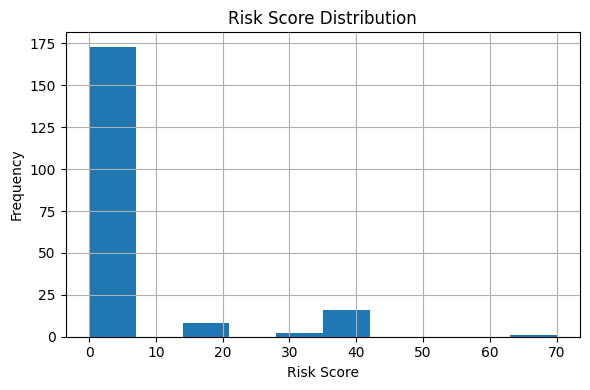

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df['risk_score'], bins=10)
plt.title("Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()


In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(df['timestamp'], df['heart_rate'])
plt.title("Heart Rate Trend")
plt.xlabel("Time")
plt.ylabel("Heart Rate (bpm)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig("heart_rate_plot.png")   # Save image
plt.close()


In [19]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib import colors
from reportlab.lib.units import inch
from datetime import datetime

doc = SimpleDocTemplate("Patient_Report.pdf")
styles = getSampleStyleSheet()
elements = []

# -------------------------
# Patient Details
# -------------------------
patient_name = "R. Sivakumar"
report_date = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

latest = df.iloc[-1]

risk_score = latest['risk_score']
alert_level = latest['alert_level']

# Risk Category
if risk_score > 70:
    risk_category = "Critical"
elif risk_score > 40:
    risk_category = "Warning"
else:
    risk_category = "Normal"

# -------------------------
# Title Section
# -------------------------
elements.append(Paragraph("AI-Driven Smart Patient Health Monitoring Report", styles["Title"]))
elements.append(Spacer(1, 20))

elements.append(Paragraph(f"<b>Patient Name:</b> {patient_name}", styles["Normal"]))
elements.append(Paragraph(f"<b>Report Generated On:</b> {report_date}", styles["Normal"]))
elements.append(Spacer(1, 15))

# -------------------------
# Latest Health Status Table
# -------------------------
data = [
    ["Parameter", "Value"],
    ["Heart Rate (bpm)", f"{latest['heart_rate']:.2f}"],
    ["SpO2 (%)", f"{latest['spo2']:.2f}"],
    ["Temperature (°C)", f"{latest['temperature']:.2f}"],
    ["Risk Score", f"{risk_score:.2f}"],
    ["Risk Category", risk_category],
    ["Alert Level", alert_level],
]

table = Table(data, colWidths=[2.5*inch, 2*inch])
table.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.grey),
    ('GRID', (0,0), (-1,-1), 1, colors.black),
    ('ALIGN', (1,1), (-1,-1), 'CENTER'),
]))

elements.append(table)
elements.append(Spacer(1, 20))

# -------------------------
# Insert Graph Image
# -------------------------
elements.append(Paragraph("Heart Rate Trend Graph", styles["Heading2"]))
elements.append(Spacer(1, 10))

img = Image("heart_rate_plot.png", width=5*inch, height=3*inch)
elements.append(img)

# -------------------------
# Final Conclusion Section
# -------------------------
elements.append(Spacer(1, 20))
elements.append(Paragraph("System Conclusion:", styles["Heading2"]))
elements.append(Spacer(1, 10))

conclusion_text = f"""
The AI-based monitoring system analyzed the patient's real-time vital parameters.
The current risk category is <b>{risk_category}</b> with a risk score of {risk_score:.2f}.
The system automatically detected health trends and generated this structured medical summary report.
"""

elements.append(Paragraph(conclusion_text, styles["Normal"]))

# -------------------------
# Build PDF
# -------------------------
doc.build(elements)

print("Professional Patient Report Generated Successfully.")


Professional Patient Report Generated Successfully.
